# Debugging Using Langsmith

In [1]:
import os
from dotenv import load_dotenv

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
from langchain_groq import ChatGroq
from IPython.display import Image, display

c:\Users\viren\generative-ai-implementations\langchain\langchain-updated\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = os.getenv("LANGSMITH_PROJECT")
os.environ["LANGSMITH_TRACING_V2"] = os.getenv("LANGSMITH_TRACING_V2")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [3]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [ ]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

@tool
def add(a:float,b:float):
    """Add two number"""
    return a+b
tools=[add]

tool_node=ToolNode([add])

llm_with_tool=llm.bind_tools([add])

def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}

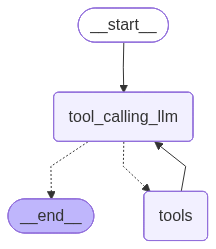

In [6]:
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

graph=builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
response=graph.invoke({"messages":"What is machine learning"})
response

{'messages': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}, id='8e0a6248-ab51-41d2-a7e4-5ae5630a38a9'),
  AIMessage(content='Machine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform a specific task without using explicit instructions. Instead, the machine learns from data, identifying patterns and making decisions based on that data.\n\nThere are several types of machine learning, including:\n\n1. **Supervised learning**: The machine is trained on labeled data, where the correct output is already known. The goal is to learn a mapping between input data and the corresponding output labels.\n2. **Unsupervised learning**: The machine is trained on unlabeled data, and the goal is to discover patterns, relationships, or groupings in the data.\n3. **Reinforcement learning**: The machine learns by interacting with an environment and receiving rewards or p

In [8]:
response=graph.invoke({"messages":"what is 5 plus 20"})
response

{'messages': [HumanMessage(content='what is 5 plus 20', additional_kwargs={}, response_metadata={}, id='6318842d-aa05-440c-bbfe-2eb31aa76127'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dy202h9f0', 'function': {'arguments': '{"a":5,"b":20}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 219, 'total_tokens': 237, 'completion_time': 0.054273509, 'completion_tokens_details': None, 'prompt_time': 0.011663535, 'prompt_tokens_details': None, 'queue_time': 0.052966054, 'total_time': 0.065937044}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f7236-7c3d-7c23-8635-f48820cdad43-0', tool_calls=[{'name': 'add', 'args': {'a': 5, 'b': 20}, 'id': 'dy202h9f0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 219, 'output_tokens':